In [15]:
import sys, torch
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
sys.path.append('../')
from utilities import convert_Pass2tensor, generate_matrix, load_embedding, print_exams
from torch.utils.data import Dataset, DataLoader
from DMS_utilities import fasta_to_dict

In [3]:
def load_crick(path, suffix, id_cols, keep_cols, rename_map, subset=False):
    df = pd.read_csv(path)

    # 只对存在的 id 列加后缀（以防有的文件列不全）
    existing_id_cols = [c for c in id_cols if c in df.columns]
    df[existing_id_cols] = df[existing_id_cols].add(f'_{suffix}')

    if subset:
        # 只选文件里真正存在的列，避免 KeyError
        existing_keep_cols = [c for c in keep_cols if c in df.columns]
        df = df[existing_keep_cols]

        # 只重命名实际存在的列
        effective_rename = {k: v for k, v in rename_map.items() if k in df.columns}
        if effective_rename:
            df = df.rename(columns=effective_rename)

    return df

class fluProfiler_Dataset(Dataset):
    def __init__(self, DataFrame):
        self.emb_file_name_a = ('matrix_' + DataFrame['seq_id_a']).tolist()
        self.emb_file_name_b = ('matrix_' + DataFrame['seq_id_b']).tolist()
        self.emb_file_name_c = ('matrix_' + DataFrame['seq_id_c']).tolist()
        self.emb_file_name_d = ('matrix_' + DataFrame['seq_id_d']).tolist()

        self.strainPassCats = convert_Pass2tensor(('<cls>' + DataFrame['serumPassCat'] + '<eos>' + DataFrame['virusPassCat'] + '<eos>').tolist())

        self.labels = torch.tensor(DataFrame['label'].tolist())
    
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        return self.emb_file_name_a[idx], self.emb_file_name_b[idx], self.emb_file_name_c[idx], self.emb_file_name_d[idx], \
               self.strainPassCats[idx], self.labels[idx]


In [4]:
import torch
import pandas as pd

device = torch.device('cuda:1')
id_cols = ['seq_id_a', 'seq_id_b', 'seq_id_c', 'seq_id_d']
keep_cols = id_cols + ['seq_a', 'seq_b', 'seq_c', 'seq_d', 'serumPassCat', 'virusPassCat', 'serumName', 'virusName',
                        'serumDate', 'virusDate','serumType', 'serumIslID', 'virusIslID', 'HI_Dist']
rename_map = {'serumType': 'Type', 'HI_Dist': 'label',}

Crick_early = load_crick('../../data/data_40/all.csv', 'early', id_cols, keep_cols, rename_map)
Crick_2024NH = load_crick('../../data/data_40/Vaccination_41.csv', '2024NH', id_cols, keep_cols, rename_map)
Crick_2024SH = load_crick('../../data/data_40/Vaccination_42.csv', '2024SH', id_cols, keep_cols, rename_map)
Crick_2025NH = load_crick('../../data/data_40/Vaccination_43.csv', '2025NH', id_cols, keep_cols, rename_map)

origin_sequence = fasta_to_dict('./Sequence/Vaccine_strain_Croatia.fasta')
DMS_sequence = fasta_to_dict('./Sequence/DMS_17_345-nature.fasta')

In [5]:
## serum selection
candidate_df = pd.concat([Crick_early, Crick_2024NH, Crick_2024SH, Crick_2025NH])
groupby_columns = ['seq_a', 'seq_b', 'serumPassCat']
agg_dict = {'seq_id_a': 'first', 'seq_id_b': 'first', 'label': 'mean', 'serumName': 'first', 'serumIslID': 'first'}
H3_serum = candidate_df.loc[candidate_df['Type'] == 'H3N2'].groupby(groupby_columns).agg(agg_dict).reset_index()
## virus selection
groupby_columns = ['seq_c', 'seq_d', 'virusPassCat']
agg_dict = {'seq_id_c': 'first', 'seq_id_d': 'first', 'label': 'mean', 'virusName': 'first', 'virusIslID': 'first'}
H3_virus = Crick_2025NH.loc[Crick_2025NH['Type'] == 'H3N2'].groupby(groupby_columns).agg(agg_dict).reset_index()

In [7]:
n = len(DMS_sequence)
DMS_serum = pd.DataFrame({'seq_a':DMS_sequence.values(), 'seq_b': [origin_sequence['NA']] * n, 'serumPassCat': ['<EGG>'] * n, 
              'seq_id_a': DMS_sequence.keys(), 'seq_id_b': ['NA'] * n, 'label': [0] * n, 
              'serumName': DMS_sequence.keys(), 'serumIslID': DMS_sequence.keys()})

candidate_serum = pd.concat([DMS_serum, H3_serum])

In [8]:
seq_names = pd.concat([candidate_serum['seq_id_a'], candidate_serum['seq_id_b'], H3_virus['seq_id_c'], H3_virus['seq_id_d']]).unique().tolist()
file_names = ['matrix_' + ID + '.pt' for ID in seq_names]

file_names_DMS = []
file_names_early = []
file_names_2024NH = []
file_names_2024SH = []
file_names_2025NH = []
for f in file_names:
    if '_2024NH' in f:
        file_names_2024NH.append(f.replace('_2024NH', ''))
    elif '_2024SH' in f:
        file_names_2024SH.append(f.replace('_2024SH', ''))
    elif '_2025NH' in f:
        file_names_2025NH.append(f.replace('_2025NH', ''))
    elif '_early' in f:
        file_names_early.append(f.replace('_early', ''))
    else:
        file_names_DMS.append(f)

In [9]:
emb_dict_DMS = load_embedding('./embedding/', map_location=device)
emb_dict_early = load_embedding('../../data/data_40/embedding_Crick', files=file_names_early, map_location=device)
emb_dict_2024NH = load_embedding('../../data/data_40/embedding_vac_41',files=file_names_2024NH,map_location=device)
emb_dict_2024SH = load_embedding('../../data/data_40/embedding_vac_42',files=file_names_2024SH,map_location=device)
emb_dict_2025NH = load_embedding('../../data/data_40/embedding_vac_43',files=file_names_2025NH,map_location=device)
emb_dict_early = {key + '_early': value for key, value in emb_dict_early.items()}
emb_dict_2024NH = {key + '_2024NH': value for key, value in emb_dict_2024NH.items()}
emb_dict_2024SH = {key + '_2024SH': value for key, value in emb_dict_2024SH.items()}
emb_dict_2025NH = {key + '_2025NH': value for key, value in emb_dict_2025NH.items()}

emb_dict = emb_dict_DMS | emb_dict_early | emb_dict_2024NH | emb_dict_2024SH | emb_dict_2025NH

Loading tensor: 100%|██████████| 236/236 [00:09<00:00, 25.95file/s]
Loading tensor: 0file [00:00, ?file/s]
Loading tensor: 100%|██████████| 380/380 [00:14<00:00, 26.48file/s]


In [11]:
test_df = candidate_serum.merge(H3_virus, how='cross')
test_df['label'] = 0
test_dataset = fluProfiler_Dataset(test_df)
test_dataloader = DataLoader(test_dataset, batch_size=256, shuffle=False)

In [12]:
import torch
from tqdm.auto import tqdm  # 新增：progress bar

model = torch.load('../../trained_model/Vaccine_model/model_to_2024SH/2025-11-19_12-06-25.pth',
                   weights_only=False, map_location=device)

prediction_ls_test = []
reference_ls_test = []
logits_ls = []
loss_ls_test = []

model.eval()

# 用 tqdm 包一层 dataloader，加个描述和总长度（如果有 __len__）
for batch in tqdm(test_dataloader, desc="Evaluating on test set", total=len(test_dataloader)):
    emb_file_name_a, emb_file_name_b, emb_file_name_c, emb_file_name_d, strainPassCats, labels = batch

    matrixs_a, masks_a = generate_matrix([emb_dict[key] for key in emb_file_name_a])
    matrixs_b, masks_b = generate_matrix([emb_dict[key] for key in emb_file_name_b])
    matrixs_c, masks_c = generate_matrix([emb_dict[key] for key in emb_file_name_c])
    matrixs_d, masks_d = generate_matrix([emb_dict[key] for key in emb_file_name_d])

    # 如果需要，把 matrix 也搬到 device：
    # matrixs_a, matrixs_b, matrixs_c, matrixs_d = (
    #     matrixs_a.to(device), matrixs_b.to(device),
    #     matrixs_c.to(device), matrixs_d.to(device)
    # )

    masks_a = masks_a.to(device)
    masks_b = masks_b.to(device)
    masks_c = masks_c.to(device)
    masks_d = masks_d.to(device)

    strainPassCats = strainPassCats.to(device)
    labels = labels.to(device)

    with torch.no_grad():
        loss, logits, output = model(
            matrices_a=matrixs_a, matrices_b=matrixs_b,
            matrices_c=matrixs_c, matrices_d=matrixs_d,
            matrix_attention_masks_a=masks_a,
            matrix_attention_masks_b=masks_b,
            matrix_attention_masks_c=masks_c,
            matrix_attention_masks_d=masks_d,
            strainPassCats=strainPassCats,
            labels=labels
        )

    loss_ls_test.append(loss.item())
    logits_ls.append(logits.tolist())
    prediction_ls_test.extend(output.view(-1).tolist())
    reference_ls_test.extend(labels.tolist())

test_mae, test_mse, test_pearson, test_spearman, test_R2 = print_exams(
    reference_ls_test, prediction_ls_test
)
test_df['prediction'] = prediction_ls_test


Evaluating on test set:   0%|          | 0/961 [00:00<?, ?it/s]

MAE: 1.05519
MSE: 2.02643
pearson correlation: nan
spearman correlation: nan
R2_score: -1.11278


/mnt/zzbnew/peixunban/chenyihao/fluProfiler/src/Section5_DMS/../utilities.py:72: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  MAE, MSE, Pearson, Spearman, R2 = mean_absolute_error(O, P), mean_squared_error(O, P), pearsonr(O, P), spearmanr(O, P), r2_score(O, P)


In [14]:
vaccine = test_df.groupby(['seq_a', 'seq_b', 'serumPassCat']).agg({'prediction': 'mean', 'serumName': 'first', 'serumIslID': 'first'}).reset_index()
vaccine['vaccine'] = vaccine['serumName'] + ' ' + vaccine['serumPassCat'].str.replace('<', '').str.replace('>', '')
vaccine['prediction'] = vaccine['prediction'] * -1
vaccine = vaccine.sort_values(by='prediction', ascending=False)
# vaccine.to_csv('../../Figure/Table S1.csv', index=False)

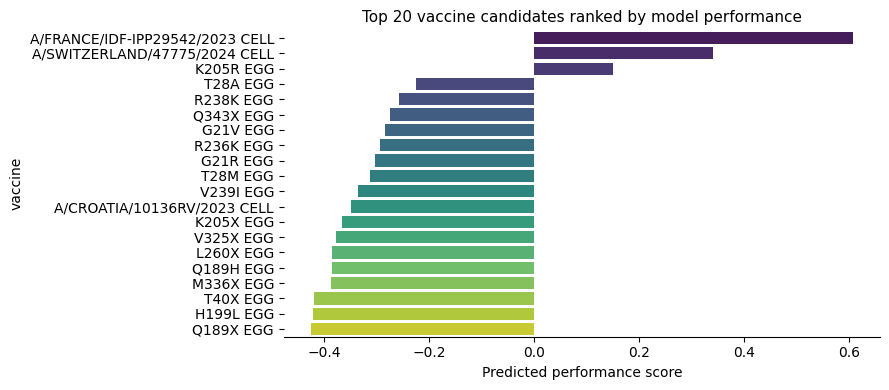

In [16]:
plt.figure(figsize=(9,4))
top20 = vaccine.sort_values('prediction', ascending=False).head(20)
sns.barplot(
    data=top20,
    y='vaccine',
    x='prediction',
    # order=top20['serumName'],
    palette='viridis',
    errorbar=None
)
sns.despine(left=True)
plt.xlabel('Predicted performance score', fontsize=10)
plt.title('Top 20 vaccine candidates ranked by model performance', fontsize=11)
plt.tight_layout()
